In [18]:
# Импортируем библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
layers = tf.keras.layers

In [19]:
# Загрузим данные 
images = np.load('/mnt/ml/ml/data/mds/images.npy')
labels = np.load('/mnt/ml/ml/data/mds/labels.npy')
images_sub = np.load('/mnt/ml/ml/data/mds/images_sub.npy')
print(f'images: {images.shape} of type {images.dtype}')
print(f'labels: {labels.shape} of type {labels.dtype}')
print(f'images_sub: {images_sub.shape} of type {images_sub.dtype}')

images: (20000, 48, 48, 3) of type uint8
labels: (20000,) of type int64
images_sub: (50000, 48, 48, 3) of type uint8


In [20]:
# Версии Tf и Keras
print("TF", tf.__version__)
print("Keras", tf.keras.__version__)

TF 2.19.0
Keras 3.10.0


In [21]:
# Проверка GPU
!nvidia-smi

Tue Jun 10 04:36:22 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.133.20             Driver Version: 570.133.20     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4080 ...    Off |   00000000:01:00.0 Off |                  N/A |
|  0%   41C    P8              6W /  320W |   14443MiB /  16376MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Посмотрим, как выглядят изображения.

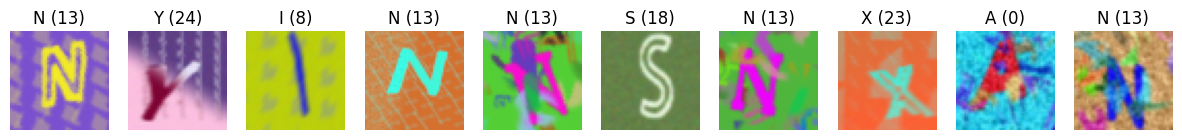

In [22]:
# Функция вывода n изображений с метками
def show_images(images, labels=None, n=10):
    plt.figure(figsize=(15, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(images[i])
        plt.axis('off')
        if labels is not None:
            letter = chr(labels[i] + ord('A'))
            plt.title(f'{letter} ({labels[i]})')
    plt.show()

# Выведем 10 первых изображений
show_images(images, labels, n=10)


Посмотрим на распределение классов в обучающих данных

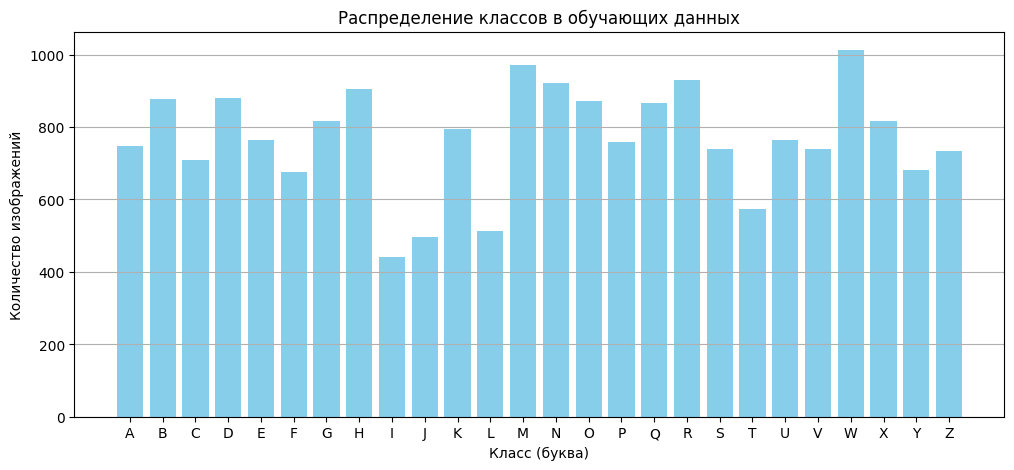

In [23]:
# Функция для визуализации классов
def class_distr(labels):
    counts = np.bincount(labels, minlength=26)
    letters = [chr(i + ord('A')) for i in range(26)]

    plt.figure(figsize=(12, 5))
    plt.bar(letters, counts, color='skyblue')
    plt.xlabel('Класс (буква)')
    plt.ylabel('Количество изображений')
    plt.title('Распределение классов в обучающих данных')
    plt.grid(axis='y')
    plt.show()

# Выведем распределение классов
class_distr(labels)

In [24]:
# нормализация изображений в диапазон [0, 1]
images = images.astype('float32') / 255.0
images_sub = images_sub.astype('float32') / 255.0

In [25]:
# количество классов
num_classes = 26
# форма входных изображений
input_shape = (48, 48, 3)

#### Собираем свёрточную нейросеть (CNN)

In [26]:
# очищаем сессию
tf.keras.backend.clear_session()

In [27]:

model = tf.keras.Sequential([
    # Входной слой
    layers.Input(shape=(48, 48, 3)),

    # Первый сверточный блок: два Conv2D + Batch + MaxPooling + Dropout
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Второй сверточный блок 128 фильтров
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Третий сверточный блок 256 фильтров
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Переход к полносвязной части
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Выходной слой 26 нейронов по числу классов, softmax — для вероятностей
    layers.Dense(num_classes, activation='softmax')
])

In [28]:
# компиляция модели
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# сохранение лучшей модели по val_accuracy
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# обучение модели
history = model.fit(
    images, labels,
    batch_size=64,
    epochs=50,  
    validation_split=0.1,
    shuffle=True,
    callbacks=[checkpoint]  # сохраняем лучшую модель во время обучения
)


Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0603 - loss: 3.6784
Epoch 1: val_accuracy improved from -inf to 0.02850, saving model to best_model.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.0604 - loss: 3.6773 - val_accuracy: 0.0285 - val_loss: 3.8154
Epoch 2/50
275/282 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3782 - loss: 2.1265
Epoch 2: val_accuracy improved from 0.02850 to 0.65450, saving model to best_model.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.3815 - loss: 2.1145 - val_accuracy: 0.6545 - val_loss: 1.1737
Epoch 3/50
276/282 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7003 - loss: 0.9861
Epoch 3: val_accuracy improved from 0.65450 to 0.74850, saving model to best_model.keras
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7011 - loss: 0.9833 - val_accuracy: 0.7485 - val_loss: 0.8030
Epoch 4/50
276/282 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8196 - loss: 0.5809
Epoch 4: val_accuracy improved from 0.7

In [29]:
# Загрузим лучшую модель
model = tf.keras.models.load_model('best_model.keras')

In [30]:
# функция визуализации Accuracy и Loss
def train_history(history):
    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title('Точность (Accuracy)')
    plt.xlabel('Эпоха')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Функция потерь (Loss)')
    plt.xlabel('Эпоха')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()



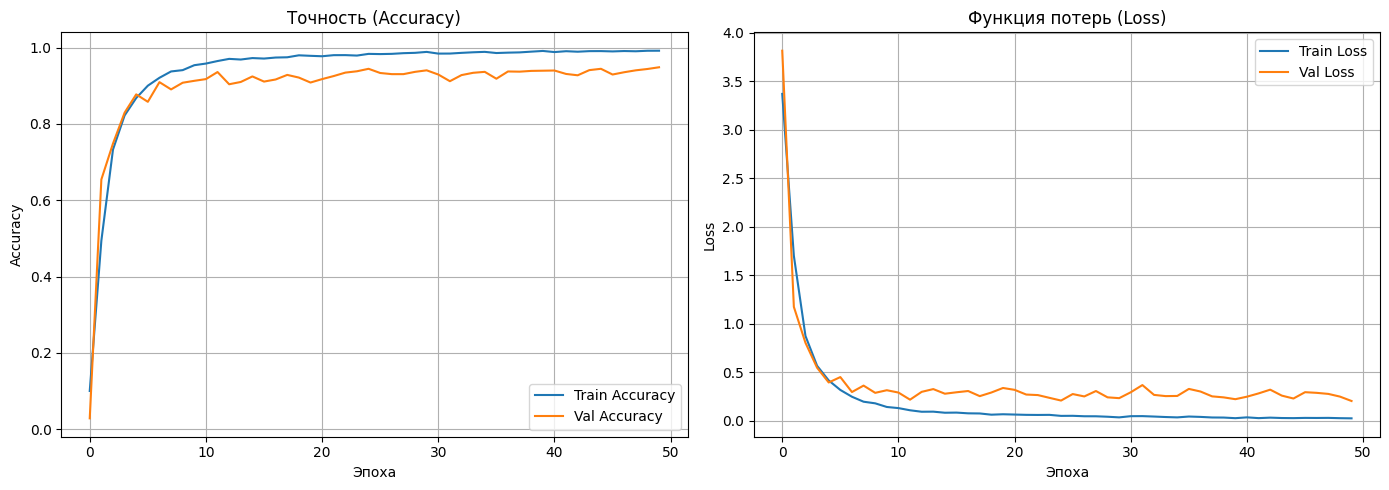

In [31]:
# визуализация Accuracy и Loss
train_history(history)

- С ~20 эпохи val_accuracy почти не растёт.
- val_loss скачет вокруг 0.3–0.4.
- Модель достигла предела полезного обучения на этих данных

In [32]:
# предсказание классов для новых изображений
predictions = model.predict(images_sub)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step


In [33]:
# Выбираем максимальную вероятность
predictions = predictions.argmax(axis = 1)
print(predictions.shape)
# посмотрим первые 10 предсказаний
print(predictions[:10]) 

(50000,)
[19  8 14 12 10  7  5 17 23 22]


In [34]:
# создание DataFrame
submission = pd.DataFrame()
# заполняем Id значениями
submission['Id'] = list(range(len(predictions)))
# заполняем Category предсказанными метками классов
submission['Category'] = predictions
# сохраняем
submission.to_csv('submission.csv', index = False)